# Track B — 69개 변수 모델 튜닝 + 교차검증 (track_b_07)

담당: 김태헌 | 선행 노트북: track_b_01~06 (서윤)

## 이 노트북의 목적

track_b_05/06에서 나온 모든 수치(AUC 0.7824, 정확도 72.46%, 등급별 정밀도-재현율 표 등)는 **고정 하이퍼파라미터 + 1회 train/test 분할**로 낸 1차 방향성 확인치였다. 이 노트북은 서윤이 전달한 3개 CSV 중 `track_b_features_train_v2.csv`(69개 변수, 신용이력 보유군 285,890명)를 가지고:

1. 로지스틱회귀(baseline) · 랜덤포레스트 · XGBoost(기존 메인모델) **세 알고리즘을 5-fold 교차검증으로 비교**(기획서 5.3)
2. 각 알고리즘을 `RandomizedSearchCV`로 하이퍼파라미터 튜닝
3. **PR-AUC를 기준 지표로 채택**(track_b_06에서 정확도 부적합을 직접 증명했던 근거를 그대로 따름)
4. 최종 선정 모델로 hold-out test 재평가 + 씬파일러(`track_b_features_apply_v2.csv`) 스코어링

**주의**: `track_b_traditional_credit_features_for_H4comparison.csv`(26개 변수)는 이 노트북에서 다루지 않는다. H4/H7 재검증은 같은 튜닝 파이프라인을 26개 변수에 그대로 적용하는 별도 노트북(다음 단계)에서 진행한다.


## 0. 환경 설정

In [1]:
# 로컬 환경: 터미널에서 아래 명령어로 한 번만 설치해두면 됨 (노트북 안에서 실행할 필요 없음)
# pip install "xgboost<3.0" shap
#
# XGBoost 3.0 이상은 base_score가 list 형태로 저장되어 SHAP TreeExplainer(Python 3.10)와 호환이 안 됨 -> 3.0 미만 고정


In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)
import xgboost as xgb
import shap

RANDOM_STATE = 42


## 1. 데이터 로드

`handoff_path`를 로컬 컴퓨터에서 CSV 3개가 있는 실제 폴더 경로로 한 줄만 수정하면 된다.

In [3]:
handoff_path = r'C:\Users\tehun\Desktop\multicamp\프로젝트\creditscore\cardCB'  # 서윤 전달 CSV 3개가 있는 로컬 폴더 경로로 수정 (Windows는 r'...' 형태 유지)

df_train = pd.read_csv(f'{handoff_path}/track_b_features_train_v2.csv')
df_apply = pd.read_csv(f'{handoff_path}/track_b_features_apply_v2.csv')  # 씬파일러 적용용, 정답 없음

print(f"train: {df_train.shape}, apply(씬파일러): {df_apply.shape}")
print(f"TARGET 양성비율: {df_train['TARGET'].mean():.4%}")


train: (285890, 71), apply(씬파일러): (44110, 70)
TARGET 양성비율: 4.2282%


## 2. 범주형 변수 원-핫 인코딩

`JB_TP`(직업유형, 6종), `HOME_ADM`(거주지역, 17종)은 숫자로 저장돼 있지만 순서 없는 코드값이라 원-핫 인코딩한다. 인코딩 기준(컬럼 목록)은 반드시 **학습 데이터(train)에서만 확정**하고, 씬파일러(apply) 쪽은 그 기준에 맞춰 정렬한다 — 씬파일러에 학습 데이터에 없는 카테고리가 있으면 무시되고, 학습 데이터에 있는데 씬파일러에 없는 카테고리는 0으로 채워진다.

In [4]:
categorical_cols = ['JB_TP', 'HOME_ADM']
feature_cols = [c for c in df_train.columns if c not in ['CUST_ID', 'TARGET']]

X_full = df_train[feature_cols]
y_full = df_train['TARGET']

X_full_enc = pd.get_dummies(X_full, columns=categorical_cols, prefix=categorical_cols)
final_feature_cols = X_full_enc.columns.tolist()

X_apply_enc = pd.get_dummies(df_apply[feature_cols], columns=categorical_cols, prefix=categorical_cols)
X_apply_enc = X_apply_enc.reindex(columns=final_feature_cols, fill_value=0)

print(f"원-핫 인코딩 후 변수 개수: {len(final_feature_cols)}개 (원본 69개 -> 확장)")


원-핫 인코딩 후 변수 개수: 90개 (원본 69개 -> 확장)


## 3. Train / Test 분리 (최종 hold-out)

튜닝·교차검증은 전부 train 쪽에서만 진행하고, test는 마지막 최종 비교에만 쓴다. 클래스 비율(4.2%)을 유지하기 위해 `stratify=y_full` 적용.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full_enc, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 양성비율: {y_train.mean():.4%} / Test 양성비율: {y_test.mean():.4%}")


Train: (228712, 90), Test: (57178, 90)
Train 양성비율: 4.2280% / Test 양성비율: 4.2289%


## 4. 교차검증 설계

- `StratifiedKFold(5)`: 클래스 비율(4.2%)이 fold마다 동일하게 유지되도록
- **기준 지표는 PR-AUC(`average_precision`)** — track_b_06에서 정확도가 이 데이터(양성 4.2%)에 부적합함을 직접 증명했던 결론을 그대로 따름. AUC는 보조 지표로만 참고

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PRIMARY_SCORING = 'average_precision'  # PR-AUC


## 5. 로지스틱회귀 튜닝 (baseline)

스케일 차이 때문에 track_b_02에서도 표준화가 필요했던 것과 동일한 이유로 `StandardScaler`를 파이프라인에 포함한다. `class_weight='balanced'`로 클래스 불균형 처리.

In [7]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
])

lr_param_dist = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],  # l1/l2 둘 다 지원
}

lr_search = RandomizedSearchCV(
    lr_pipeline, lr_param_dist, n_iter=12, scoring=PRIMARY_SCORING,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
lr_search.fit(X_train, y_train)

print(f"[LogisticRegression] 최적 파라미터: {lr_search.best_params_}")
print(f"[LogisticRegression] CV PR-AUC: {lr_search.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits
[LogisticRegression] 최적 파라미터: {'clf__solver': 'liblinear', 'clf__penalty': 'l1', 'clf__C': 0.01}
[LogisticRegression] CV PR-AUC: 0.1216


## 6. 랜덤포레스트 튜닝 (기획서 5.3 비교 대상)

In [8]:
rf_param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 10, 15],  # None(완전성장) 제거 -> SHAP 계산폭주 방지 + 과적합 방지, 상한 15로 대체
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2', 0.3],
    'class_weight': ['balanced', 'balanced_subsample'],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_dist, n_iter=20, scoring=PRIMARY_SCORING,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f"[RandomForest] 최적 파라미터: {rf_search.best_params_}")
print(f"[RandomForest] CV PR-AUC: {rf_search.best_score_:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[RandomForest] 최적 파라미터: {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 15, 'class_weight': 'balanced_subsample'}
[RandomForest] CV PR-AUC: 0.2208


## 7. XGBoost 튜닝 (기존 메인모델)

track_b_04에서 고정 하이퍼파라미터(n_estimators=300, max_depth=4, learning_rate=0.05)로 AUC 0.7824, PR-AUC 0.1820이 나왔던 모델. `scale_pos_weight`는 train 기준으로 새로 계산.

In [9]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method='hist',
    ),
    xgb_param_dist, n_iter=30, scoring=PRIMARY_SCORING,
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f"[XGBoost] 최적 파라미터: {xgb_search.best_params_}")
print(f"[XGBoost] CV PR-AUC: {xgb_search.best_score_:.4f}")


scale_pos_weight: 22.65
Fitting 5 folds for each of 30 candidates, totalling 150 fits
[XGBoost] 최적 파라미터: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.6}
[XGBoost] CV PR-AUC: 0.2550


## 8. 세 모델 최종 비교 (hold-out test)

In [10]:
searches = {
    'LogisticRegression': lr_search,
    'RandomForest': rf_search,
    'XGBoost': xgb_search,
}

results = []
for name, search in searches.items():
    proba = search.best_estimator_.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    prauc = average_precision_score(y_test, proba)
    results.append({
        'model': name,
        'cv_prauc': search.best_score_,
        'test_auc': auc,
        'test_prauc': prauc,
    })

comparison_df = pd.DataFrame(results).sort_values('test_prauc', ascending=False).reset_index(drop=True)
comparison_df


,model,cv_prauc,test_auc,test_prauc
0,XGBoost,0.255033,0.839622,0.265754
1,RandomForest,0.220828,0.829545,0.220163
2,LogisticRegression,0.121634,0.727020,0.122941


## 9. 최적 모델 선정

**PR-AUC(test) 기준**으로 선정한다. AUC는 참고용.

In [11]:
best_row = comparison_df.iloc[0]
best_model_name = best_row['model']
best_model = searches[best_model_name].best_estimator_

print(f"최종 선정 모델: {best_model_name}")
print(f"Test AUC: {best_row['test_auc']:.4f} / Test PR-AUC: {best_row['test_prauc']:.4f}")


최종 선정 모델: XGBoost
Test AUC: 0.8396 / Test PR-AUC: 0.2658


## 10. 최종 모델 상세 평가

In [12]:
proba_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(classification_report(y_test, pred_test, target_names=['정상(0)', '연체(1)']))
print("혼동행렬:")
print(confusion_matrix(y_test, pred_test))

# 참고: track_b_06 결론에 따라 임계값 0.5의 정확도는 참고용일 뿐,
# 실제 활용 시에는 등급별 정밀도-재현율 표(컷오프 선택)를 우선한다.


              precision    recall  f1-score   support

       정상(0)       0.98      0.89      0.93     54760
       연체(1)       0.19      0.57      0.28      2418

    accuracy                           0.88     57178
   macro avg       0.58      0.73      0.61     57178
weighted avg       0.95      0.88      0.90     57178

혼동행렬:
[[48735  6025]
 [ 1036  1382]]


## 11. 변수 중요도 확인

트리 기반 모델이 선정된 경우 SHAP, 로지스틱회귀가 선정된 경우 계수로 확인한다.

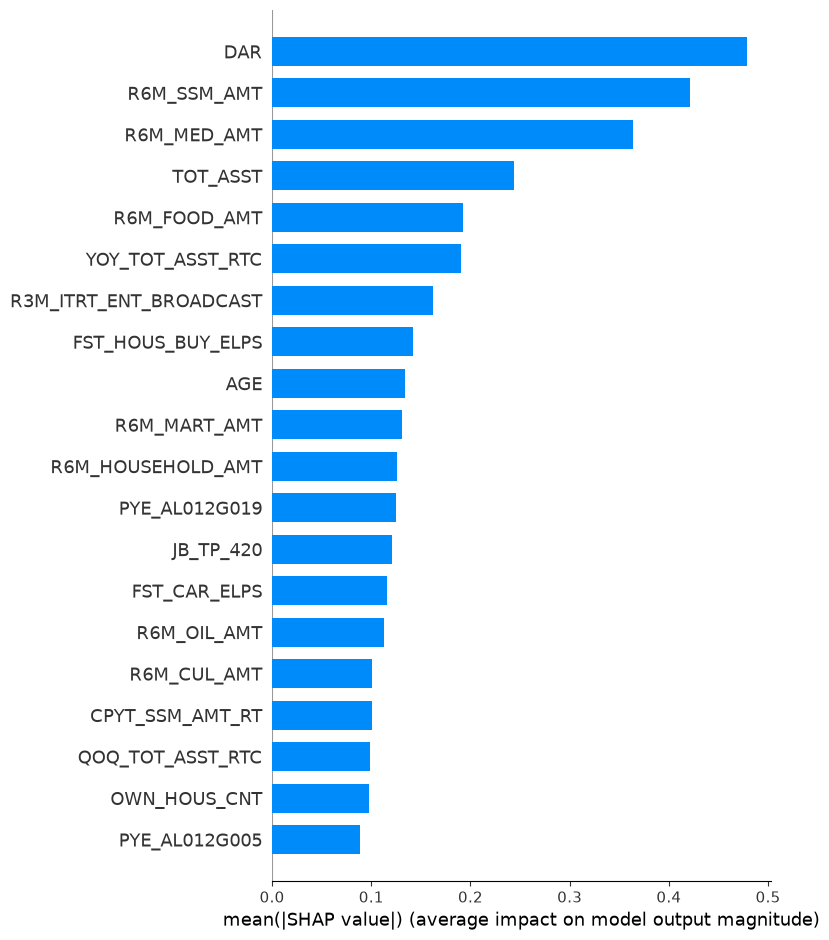

In [13]:
if best_model_name in ('XGBoost', 'RandomForest'):
    # RandomForest는 max_depth=None으로 뽑히면 트리가 매우 깊어질 수 있음 -> 실제 깊이 확인
    use_shap = True
    if best_model_name == 'RandomForest':
        actual_depths = [est.get_depth() for est in best_model.estimators_[:20]]  # 앞 20그루만 샘플 확인
        max_depth_seen = max(actual_depths)
        print(f"RandomForest 실제 트리 깊이(샘플 20그루 중 최대): {max_depth_seen}")
        if max_depth_seen > 15:
            use_shap = False
            print("-> 깊이가 너무 깊어 SHAP 대신 permutation importance로 대체")

    if use_shap:
        explainer = shap.TreeExplainer(best_model)
        sample_n = 500 if best_model_name == 'RandomForest' else 5000
        X_shap_sample = X_test.sample(min(sample_n, len(X_test)), random_state=RANDOM_STATE)
        shap_values = explainer.shap_values(X_shap_sample)
        sv = shap_values[1] if isinstance(shap_values, list) else shap_values
        shap.summary_plot(sv, X_shap_sample, plot_type='bar', max_display=20)
    else:
        from sklearn.inspection import permutation_importance
        perm = permutation_importance(
            best_model, X_test, y_test,
            scoring='average_precision', n_repeats=5,
            random_state=RANDOM_STATE, n_jobs=-1
        )
        perm_df = pd.DataFrame({
            'feature': X_test.columns,
            'importance_mean': perm.importances_mean,
            'importance_std': perm.importances_std,
        }).sort_values('importance_mean', ascending=False)
        print(perm_df.head(20))
else:
    coef_df = pd.DataFrame({
        'feature': X_train.columns,
        'coef': best_model.named_steps['clf'].coef_[0],
    }).sort_values('coef', key=abs, ascending=False)
    print(coef_df.head(20))


## 12. 씬파일러 스코어링

씬파일러는 정답이 없으므로 예측이 아닌 **참고 점수**로 프레이밍한다(track_b_05 결론과 동일).

In [14]:
thin_proba = best_model.predict_proba(X_apply_enc)[:, 1]

df_apply_scored = df_apply[['CUST_ID']].copy()
df_apply_scored['score_thin_filers'] = thin_proba

print(df_apply_scored['score_thin_filers'].describe())

df_apply_scored.to_csv(f'{handoff_path}/track_b_thin_filer_scores_final.csv', index=False)
print("저장 완료: track_b_thin_filer_scores_final.csv")


count    44110.000000
mean         0.240481
std          0.181920
min          0.000039
25%          0.092745
50%          0.206549
75%          0.350657
max          0.948887
Name: score_thin_filers, dtype: float64
저장 완료: track_b_thin_filer_scores_final.csv


## 13. 결과 저장 (비교표 + 최적 파라미터)

In [15]:
comparison_df.to_csv(f'{handoff_path}/track_b_model_comparison_final.csv', index=False)

best_params_record = {
    'LogisticRegression': lr_search.best_params_,
    'RandomForest': rf_search.best_params_,
    'XGBoost': xgb_search.best_params_,
    'selected_model': best_model_name,
    'selected_test_auc': float(best_row['test_auc']),
    'selected_test_prauc': float(best_row['test_prauc']),
}

with open(f'{handoff_path}/track_b_best_params_final.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_record, f, ensure_ascii=False, indent=2, default=str)

print("최종 산출물 저장 완료")
print(comparison_df)


최종 산출물 저장 완료
                model  cv_prauc  test_auc  test_prauc
0             XGBoost  0.255033  0.839622    0.265754
1        RandomForest  0.220828  0.829545    0.220163
2  LogisticRegression  0.121634  0.727020    0.122941


## 다음 단계

1. **H4 재검증**: 이 노트북과 동일한 튜닝 파이프라인을 `track_b_traditional_credit_features_for_H4comparison.csv`(26개 변수)에 적용해서, track_b_05의 "+3.07%p" 방향성 확인치를 정식 수치로 재확정
2. **등급표 재계산**: track_b_06의 컷오프별 정밀도-재현율 표를 이 노트북의 최종 선정 모델 `proba_test` 기준으로 재생성
3. 최종 선정 모델이 XGBoost가 아닐 경우, track_b_04/05/06에서 XGBoost 기준으로 서술된 SHAP 해석·수치들을 새 모델 기준으로 다시 확인 필요
